In [ ]:
import face_recognition as fr
import cv2
import numpy as np
import matplotlib.pyplot as plt
import pickle

In [ ]:
def show_image_with_faces_and_ids(img, face_locations, face_ids):
    for index, face_location in enumerate(face_locations):
        print(f"Found face {index} at location: {face_location}")
        t,r,b,l = face_location
        img = cv2.rectangle(img, (l,t), (r,b), (250, 5, 5), 1)
    
    plt.imshow(img)
    plt.axis("off")
    plt.show()

In [ ]:
faces_in_frame = []

In [ ]:
with open("faces.p", "rb") as f:
	faces_info = pickle.load(f)

In [ ]:
from time import sleep

camera_index = 0

cap = cv2.VideoCapture(camera_index)
cap.set(cv2.CAP_PROP_FRAME_WIDTH, 640)
cap.set(cv2.CAP_PROP_FRAME_HEIGHT, 480)

if not cap.isOpened():
    print(f"Error: Could not open video device at index {camera_index}")
    exit()

while True:
    ret, frame = cap.read()
    if not ret:
        print("Error: Failed to capture image")
        break

    # Rotate to landscape, then flip horizontally
    # frame = cv2.rotate(frame, cv2.ROTATE_90_CLOCKWISE)
    # frame = cv2.rotate(frame, cv2.ROTATE_90_CLOCKWISE)
    frame = cv2.flip(frame, 1)

    face_locations = fr.face_locations(frame, model="hog")
    if face_locations:
        print(f"Found {len(face_locations)} face(s) in the current frame.")
        user_img = frame.copy()
        
        # Get face encodings for all detected faces
        user_face_loc = fr.face_locations(user_img)
        user_face_en = fr.face_encodings(user_img, user_face_loc)
        
        # Process each detected face
        for face_idx, face_enc in enumerate(user_face_en):
            # Compare this face against all known faces
            matches = fr.compare_faces([face_info[1] for face_info in faces_info], face_enc)
            face_distances = fr.face_distance([face_info[1] for face_info in faces_info], face_enc)
            found = None
            
            # Find the first matching identity
            for i, match in enumerate(matches):
                if match:
                    found = faces_info[i][0]
                    print(f"Match found: {faces_info[i][0]}")
                    break
            
            # Draw text on frame if match found
            if found and face_idx < len(user_face_loc):
                top, right, bottom, left = user_face_loc[face_idx]
                cv2.rectangle(frame, (left, top), (right, bottom), (250, 5, 5), 1)
                cv2.putText(frame, found, (left, top - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (250, 5, 5), 1)

    cv2.imshow("Phone Camera Stream", frame)

    # Press 'q' to exit
    if cv2.waitKey(1) & 0xFF == ord('q'):
        break

cap.release()
cv2.destroyAllWindows()

Found 1 face(s) in the current frame.
Match found: 003
Found 1 face(s) in the current frame.
Match found: 003
Found 1 face(s) in the current frame.
Match found: 004
Found 1 face(s) in the current frame.
Match found: 004
Found 1 face(s) in the current frame.
Match found: 004
Found 1 face(s) in the current frame.
Match found: 004
Found 1 face(s) in the current frame.
Match found: 004
Found 1 face(s) in the current frame.
Match found: 003
Found 1 face(s) in the current frame.
Match found: 003
Found 1 face(s) in the current frame.
Match found: 004
Found 1 face(s) in the current frame.
Match found: 004
Found 1 face(s) in the current frame.
Match found: 004
Found 1 face(s) in the current frame.
Match found: 004


QFont::setPointSizeF: Point size <= 0 (-0.750000), must be greater than 0
QFont::setPointSizeF: Point size <= 0 (-0.750000), must be greater than 0
QFont::setPointSizeF: Point size <= 0 (-0.750000), must be greater than 0
QFont::setPointSizeF: Point size <= 0 (-0.750000), must be greater than 0
QFont::setPointSizeF: Point size <= 0 (-0.750000), must be greater than 0
QFont::setPointSizeF: Point size <= 0 (-0.750000), must be greater than 0
QFont::setPointSizeF: Point size <= 0 (-0.750000), must be greater than 0
QFont::setPointSizeF: Point size <= 0 (-0.750000), must be greater than 0
QFont::setPointSizeF: Point size <= 0 (-0.750000), must be greater than 0
QFont::setPointSizeF: Point size <= 0 (-0.750000), must be greater than 0
QFont::setPointSizeF: Point size <= 0 (-0.750000), must be greater than 0
QFont::setPointSizeF: Point size <= 0 (-0.750000), must be greater than 0
QFont::setPointSizeF: Point size <= 0 (-0.750000), must be greater than 0
QFont::setPointSizeF: Point size <= 0 

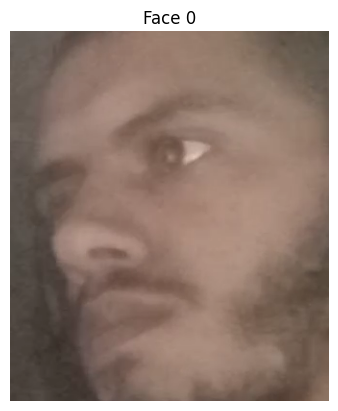

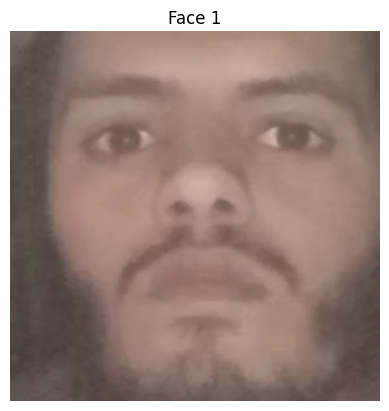

In [ ]:
for index, face in enumerate(faces_in_frame):
    face = cv2.cvtColor(face, cv2.COLOR_BGR2RGB)
    plt.imshow(face)
    plt.axis("off")
    plt.title(f"Face {index}")
    plt.show()

In [ ]:
# Load the images from images folder, get the ids and encode them
import os

images = os.listdir("images")
ids = [os.path.splitext(image)[0] for image in images]
images = [cv2.imread(f"images/{image}") for image in images]

In [ ]:
def face_encoding(face):
    face = cv2.cvtColor(face, cv2.COLOR_BGR2RGB)
    face_loc = fr.face_locations(face, model='large')
    return fr.face_encodings(face, face_loc, model='large')[0]

In [ ]:
face_encodings = [face_encoding(face) for face in images]

save file

In [ ]:
import pickle
faces_info = list(zip(ids, face_encodings))

open("faces.p", "wb").write(pickle.dumps(faces_info))

4382

load file

In [ ]:
with open("faces.p", "rb") as f:
	faces_info = pickle.load(f)

faces_info

In [ ]:
# test
new_img = cv2.imread("image.jpg")

face_loc = fr.face_locations(new_img)[0]
face_enc = fr.face_encodings(new_img)[0]

# compare the face encoding with the known face encodings
matches = fr.compare_faces([face_info[1] for face_info in faces_info], face_enc)
# print the matches and the corresponding ids
found = None
for i, match in enumerate(matches):
    if match:
        found = faces_info[i][0]
        print(f"Match found: {faces_info[i][0]}")

Match found: 001
